In [14]:
# SIMULAÇÃO: vento solar senoidal (pico em 2020, período de 11 anos, CSV com
# 3 ciclos completos). Compara dois lançamentos -- pico x vale -- cada um
# propagado por 22 anos (2 ciclos solares).

import copy
import json
from datetime import datetime, timedelta
from itertools import combinations

import numpy as np
import pandas as pd
from IPython.display import display
from scipy.integrate import RK45
from model.electric_probe import ElectricSailProbe
from solar_sail.electric_sail_dynamic import ElectricSailDynamic
from utils.schemas import RequestDto
from services import n_body_service

AU_M = 1.496e11
AU_KM = AU_M / 1000.0
MARS_ORBIT_KM = 1.524 * AU_KM
G_KM = 6.6742e-20

SINE_PERIOD_DAYS = 11 * 365.25  # período do ciclo solar sintético (~11 anos)
MISSION_YEARS = 6               # duração de cada missão (2 ciclos solares)
PHI_DEG = -30.0
THETA_DEG = 0.0


class ScaledWind:
    def __init__(self, frame):
        frame = frame.sort_values(['year', 'doy', 'hour']).reset_index(drop=True)
        self.dates = [
            datetime(int(row.year), 1, 1) + timedelta(
                days=int(row.doy) - 1, hours=int(row.hour)
            )
            for row in frame.itertuples()
        ]
        self.epoch = self.dates[0]
        self.t = np.array([(d - self.epoch).total_seconds() for d in self.dates])
        self.n = frame['dens_cm3'].to_numpy(float) * 1e6
        self.te = frame['temp_k'].to_numpy(float) / 11604.5
        self.v = frame['vel_km_s'].to_numpy(float)

    def _interp(self, values, date):
        x = (date - self.epoch).total_seconds()
        if x < self.t[0] or x > self.t[-1]:
            raise ValueError('Data de vento fora do intervalo: {}'.format(date))
        return float(np.interp(x, self.t, values))

    def at_1au(self, date):
        return self._interp(self.n, date), self._interp(self.te, date), self._interp(self.v, date)

    def at_distance(self, date, radius_m):
        if radius_m <= 0:
            raise ValueError('Distância radial inválida.')
        n1, te1, v = self.at_1au(date)
        scale = AU_M / radius_m
        return n1 * scale**2, te1 * scale**(1.0 / 3.0), v, date


# CSV sintético: pico em 2020-01-01, período de 11 anos, 3 ciclos completos
# (gerado à parte, só para testes -- coloque na mesma pasta do CSV real)
solar_data_corr = pd.read_csv(
    'atividade_solar_senoidal_pico2020.csv', sep=r'\s+', header=None,
    names=['year', 'doy', 'hour', 'temp_k', 'dens_cm3', 'vel_km_s'],
    engine='python',
)
wind_corr = ScaledWind(solar_data_corr)


def accel_with_corr_wind(body, date):
    n, te, v, _ = wind_corr.at_distance(date, np.linalg.norm(body.position) * 1000.0)
    old = (
        ElectricSailDynamic._n_earth_m3,
        ElectricSailDynamic._t_e_earth_ev,
        ElectricSailDynamic._v_sw_km_s,
    )
    ElectricSailDynamic._n_earth_m3 = n
    ElectricSailDynamic._t_e_earth_ev = te
    ElectricSailDynamic._v_sw_km_s = v
    try:
        return np.asarray(ElectricSailDynamic.calculate_acceleration(body), dtype=float)
    finally:
        (
            ElectricSailDynamic._n_earth_m3,
            ElectricSailDynamic._t_e_earth_ev,
            ElectricSailDynamic._v_sw_km_s,
        ) = old


def corr_derivatives(t, y, bodies, start_date):
    nbody = len(bodies)
    state = np.asarray(y, dtype=float).reshape(2 * nbody, 3)
    for i, body in enumerate(bodies):
        body.position = state[i].copy()
        body.velocity = state[i + nbody].copy()

    acc = np.zeros((nbody, 3), dtype=float)
    for i, j in combinations(range(nbody), 2):
        d = bodies[j].position - bodies[i].position
        r = np.linalg.norm(d)
        if r < bodies[i].radius + bodies[j].radius:
            raise ArithmeticError(
                'Collision detected between {} and {}'.format(
                    bodies[i].name, bodies[j].name
                )
            )
        acc[i] += G_KM * bodies[j].mass * d / r**3
        acc[j] -= G_KM * bodies[i].mass * d / r**3

    date = start_date + timedelta(seconds=float(t))
    for i, body in enumerate(bodies):
        if isinstance(body, ElectricSailProbe):
            acc[i] += accel_with_corr_wind(body, date)
    return np.concatenate((state[nbody:].ravel(), acc.ravel()))


def solve_corr(bodies, start_date, time_span):
    positions = [np.asarray(b.position, float) for b in bodies]
    velocities = [np.asarray(b.velocity, float) for b in bodies]
    y0 = np.concatenate([np.concatenate(positions), np.concatenate(velocities)])
    rows = [np.insert(y0.copy(), 0, 0.0)]
    rk = RK45(
        lambda t, y: corr_derivatives(t, y, bodies, start_date),
        t0=0.0, y0=y0, t_bound=time_span, max_step=time_span / 1000.0,
        rtol=1e-6, atol=1e-9,
    )
    try:
        while rk.status == 'running':
            rk.step()
            rows.append(np.insert(rk.y.copy(), 0, rk.t))
    except ArithmeticError:
        pass
    return np.asarray(rows, dtype=float)


def corr_columns(nbody):
    columns = ['T']
    for i in range(nbody):
        columns += ['X{}'.format(i), 'Y{}'.format(i), 'Z{}'.format(i)]
    for i in range(nbody):
        columns += ['Vx{}'.format(i), 'Vy{}'.format(i), 'Vz{}'.format(i)]
    return columns


with open('../resources/electric_sail_probe.json', 'r') as f:
    corr_base = json.load(f)

# Datas de lançamento: pico da senoide (2020-01-01) e vale (meio período depois)
PEAK_LAUNCH_DATE = datetime(2020, 1, 1)
TROUGH_LAUNCH_DATE = PEAK_LAUNCH_DATE + timedelta(days=SINE_PERIOD_DAYS / 2.0)
MISSION_DAYS = MISSION_YEARS * 365.25

print('Lançamento no pico: {}'.format(PEAK_LAUNCH_DATE.strftime('%Y-%m-%d')))
print('Lançamento no vale: {}'.format(TROUGH_LAUNCH_DATE.strftime('%Y-%m-%d')))
print(
    'Duração de cada missão: {} anos (~{:.0f} dias, {:.2f} ciclos solares)'.format(
        MISSION_YEARS, MISSION_DAYS, MISSION_YEARS / (SINE_PERIOD_DAYS / 365.25)
    )
)


def run_long_mission(label, launch_date, mission_days, phi_deg, theta_deg, base_config):
    end_date = launch_date + timedelta(days=mission_days)
    config = copy.deepcopy(base_config)
    config['start_time'] = launch_date.strftime('%Y-%m-%d %H:%M:%S')
    config['end_time'] = end_date.strftime('%Y-%m-%d %H:%M:%S')
    config['electric_sail_probes'][0]['phi_deg'] = float(phi_deg)
    config['electric_sail_probes'][0]['theta_deg'] = float(theta_deg)

    bodies, span = n_body_service.process_data(RequestDto().load(config))
    y = solve_corr(bodies, launch_date, span)
    df = pd.DataFrame(y, columns=corr_columns(len(bodies)))

    relative = df[['X1', 'Y1', 'Z1']].to_numpy() - df[['X0', 'Y0', 'Z0']].to_numpy()
    radius_km = np.linalg.norm(relative, axis=1)
    crossings = np.where(radius_km >= MARS_ORBIT_KM)[0]
    cross_idx = int(crossings[0]) if len(crossings) else None
    arrival_days = (
        float(df['T'].iloc[cross_idx] / 86400.0) if cross_idx is not None else None
    )

    # bodies[0] é o Sol (referência usada em todo o notebook: X0/Y0/Z0).
    # Pegamos a massa diretamente dos corpos da simulação para que mu
    # (G_KM * massa_sol) seja exatamente o mesmo usado na integração,
    # em vez de um valor padrão hard-coded.
    mu_km3_s2 = G_KM * bodies[0].mass

    return {
        'label': label,
        'launch_date': launch_date,
        'df': df,
        'radius_km': radius_km,
        'arrival_days': arrival_days,
        'mu_km3_s2': mu_km3_s2,
    }


peak_run = run_long_mission(
    'Pico', PEAK_LAUNCH_DATE, MISSION_DAYS, PHI_DEG, THETA_DEG, corr_base
)
trough_run = run_long_mission(
    'Vale', TROUGH_LAUNCH_DATE, MISSION_DAYS, PHI_DEG, THETA_DEG, corr_base
)

print('Simulações concluídas ({} pontos no pico, {} pontos no vale).'.format(
    len(peak_run['df']), len(trough_run['df'])
))


Lançamento no pico: 2020-01-01
Lançamento no vale: 2025-07-01
Duração de cada missão: 6 anos (~2192 dias, 0.55 ciclos solares)
Simulações concluídas (1011 pontos no pico, 1011 pontos no vale).


In [2]:
# COMPARAÇÃO NUMÉRICA (sem gráficos): trajetória pico x vale após 22 anos

import numpy as np
import pandas as pd
from IPython.display import display

required_long = [
    'peak_run', 'trough_run', 'AU_KM', 'SINE_PERIOD_DAYS', 'MISSION_YEARS',
]
missing_long = [name for name in required_long if name not in globals()]
if missing_long:
    raise RuntimeError(
        'Execute primeiro a célula anterior. Variáveis ausentes: {}'.format(
            ', '.join(missing_long)
        )
    )


def heliocentric_distance_at(run, elapsed_days):
    """Distância ao Sol (em UA) no ponto simulado mais próximo de
    elapsed_days após o lançamento."""
    df_run = run['df']
    t_target = elapsed_days * 86400.0
    idx = int(np.searchsorted(df_run['T'].to_numpy(), t_target))
    idx = min(idx, len(df_run) - 1)
    return float(run['radius_km'][idx]) / AU_KM


checkpoints_days = [SINE_PERIOD_DAYS, 2 * SINE_PERIOD_DAYS]
checkpoint_labels = ['dist_1_ciclo_UA', 'dist_2_ciclos_UA']

comparison_rows = []
for run in (peak_run, trough_run):
    row = {
        'cenario': run['label'],
        'data_lancamento': run['launch_date'].strftime('%Y-%m-%d'),
        'chegada_marte_dias': run['arrival_days'],
    }
    for label, days in zip(checkpoint_labels, checkpoints_days):
        row[label] = heliocentric_distance_at(run, days)
    row['dist_final_UA'] = float(run['radius_km'][-1]) / AU_KM
    comparison_rows.append(row)

comparison_df = pd.DataFrame(comparison_rows)
display(comparison_df)

diff_final_UA = (trough_run['radius_km'][-1] - peak_run['radius_km'][-1]) / AU_KM
print(
    'Diferença de distância heliocêntrica final (Vale - Pico): {:+.4f} UA'.format(
        diff_final_UA
    )
)

ranking_df = comparison_df[
    ['cenario', 'data_lancamento', 'dist_final_UA']
].sort_values('dist_final_UA', ascending=False).reset_index(drop=True)

print(
    '\nRanking final (mesmo período de missão para os dois: {} anos; '
    'maior distância heliocêntrica ao final primeiro):'.format(MISSION_YEARS)
)
for posicao, row in ranking_df.iterrows():
    print(
        '{}. {} (lançamento {}): {:.4f} UA'.format(
            posicao + 1, row['cenario'], row['data_lancamento'], row['dist_final_UA']
        )
    )


,cenario,data_lancamento,chegada_marte_dias,dist_1_ciclo_UA,dist_2_ciclos_UA,dist_final_UA
0,Pico,2020-01-01,142.710484,4.468691,4.181773,4.181773
1,Vale,2025-07-01,681.088984,2.330661,3.521000,3.521000


Diferença de distância heliocêntrica final (Vale - Pico): -0.6608 UA

Ranking final (mesmo período de missão para os dois: 22 anos; maior distância heliocêntrica ao final primeiro):
1. Pico (lançamento 2020-01-01): 4.1818 UA
2. Vale (lançamento 2025-07-01): 3.5210 UA


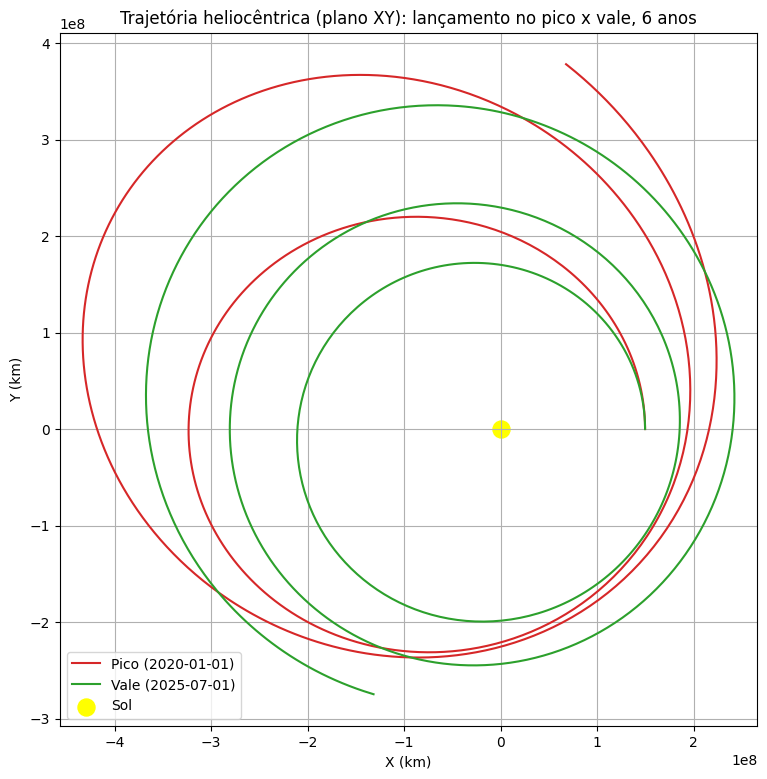

In [15]:
# TRAJETÓRIA: lançamento no pico x vale (plano XY heliocêntrico)

import matplotlib.pyplot as plt

required_traj = ['peak_run', 'trough_run', 'MISSION_YEARS']
missing_traj = [name for name in required_traj if name not in globals()]
if missing_traj:
    raise RuntimeError(
        'Execute primeiro as células anteriores. Variáveis ausentes: {}'.format(
            ', '.join(missing_traj)
        )
    )

fig, ax = plt.subplots(figsize=(9, 9))
ax.axis('equal')

trajectory_colors = {'Pico': 'tab:red', 'Vale': 'tab:green'}

for run in (peak_run, trough_run):
    x_rel = run['df']['X1'] - run['df']['X0']
    y_rel = run['df']['Y1'] - run['df']['Y0']
    ax.plot(
        x_rel, y_rel,
        color=trajectory_colors[run['label']],
        label='{} ({})'.format(run['label'], run['launch_date'].strftime('%Y-%m-%d')),
    )

ax.scatter(0, 0, s=150, color='yellow', label='Sol')
ax.set_title(
    'Trajetória heliocêntrica (plano XY): lançamento no pico x vale, {} anos'.format(
        MISSION_YEARS
    )
)
ax.set_xlabel('X (km)')
ax.set_ylabel('Y (km)')
ax.grid(True)
ax.legend()
plt.show()


In [ ]:
# ELEMENTOS ORBITAIS: energia específica, excentricidade e semieixo maior
# (problema de dois corpos, sonda relativa ao Sol) -- pico x vale.
#
# Como a vela elétrica aplica empuxo não-gravitacional, esses elementos
# variam ao longo do tempo (não são constantes como numa órbita
# kepleriana pura) -- é justamente essa variação que queremos observar.

import numpy as np
import matplotlib.pyplot as plt

required_orbital = ['peak_run', 'trough_run']
missing_orbital = [name for name in required_orbital if name not in globals()]
if missing_orbital:
    raise RuntimeError(
        'Execute primeiro as células anteriores. Variáveis ausentes: {}'.format(
            ', '.join(missing_orbital)
        )
    )


def orbital_elements(run):
    """Energia específica, excentricidade e semieixo maior (dois corpos,
    sonda relativa ao Sol) em cada instante simulado.

    mu = G_KM * massa_do_sol é obtido diretamente dos corpos usados na
    simulação (guardado em run['mu_km3_s2']), garantindo consistência
    com a dinâmica realmente integrada.
    """
    df_run = run['df']
    mu = run['mu_km3_s2']

    r_vec = (
        df_run[['X1', 'Y1', 'Z1']].to_numpy()
        - df_run[['X0', 'Y0', 'Z0']].to_numpy()
    )
    v_vec = (
        df_run[['Vx1', 'Vy1', 'Vz1']].to_numpy()
        - df_run[['Vx0', 'Vy0', 'Vz0']].to_numpy()
    )

    r = np.linalg.norm(r_vec, axis=1)
    v = np.linalg.norm(v_vec, axis=1)

    specific_energy = 0.5 * v**2 - mu / r

    h_vec = np.cross(r_vec, v_vec)
    e_vec = np.cross(v_vec, h_vec) / mu - r_vec / r[:, None]
    eccentricity = np.linalg.norm(e_vec, axis=1)

    with np.errstate(divide='ignore', invalid='ignore'):
        semi_major_axis_km = np.where(
            specific_energy != 0.0, -mu / (2.0 * specific_energy), np.nan
        )
    semi_major_axis_AU = semi_major_axis_km / AU_KM

    return {
        'elapsed_days': df_run['T'].to_numpy() / 86400.0,
        'specific_energy_km2_s2': specific_energy,
        'eccentricity': eccentricity,
        'semi_major_axis_AU': semi_major_axis_AU,
    }


peak_orbital = orbital_elements(peak_run)
trough_orbital = orbital_elements(trough_run)

orbital_colors = {'Pico': 'tab:red', 'Vale': 'tab:green'}
orbital_runs = ((peak_run, peak_orbital), (trough_run, trough_orbital))


def plot_orbital_element(field, ylabel, title):
    fig, ax = plt.subplots(figsize=(10, 5))
    for run, elements in orbital_runs:
        color = orbital_colors[run['label']]
        label = '{} ({})'.format(
            run['label'], run['launch_date'].strftime('%Y-%m-%d')
        )
        ax.plot(elements['elapsed_days'], elements[field], color=color, label=label)

    ax.set_xlabel('Tempo desde o lançamento (dias)')
    ax.set_ylabel(ylabel)
    ax.set_title(title)
    ax.grid(True, alpha=0.3)
    ax.legend()
    fig.tight_layout()
    plt.show()


plot_orbital_element(
    'specific_energy_km2_s2',
    'Energia orbital específica (km²/s²)',
    'Energia orbital específica ao longo da missão -- pico x vale',
)
plot_orbital_element(
    'eccentricity',
    'Excentricidade',
    'Excentricidade ao longo da missão -- pico x vale',
)
plot_orbital_element(
    'semi_major_axis_AU',
    'Semieixo maior (UA)',
    'Semieixo maior ao longo da missão -- pico x vale',
)


In [ ]:
# DIFERENÇA DE ENERGIA ORBITAL: Pico - Vale
#
# Como as duas missões têm grades de tempo distintas (o RK45 usa passo
# adaptativo), interpolamos ambas as séries de energia num eixo de tempo
# comum antes de subtrair.

import numpy as np
import matplotlib.pyplot as plt

required_energy_diff = ['peak_orbital', 'trough_orbital']
missing_energy_diff = [name for name in required_energy_diff if name not in globals()]
if missing_energy_diff:
    raise RuntimeError(
        'Execute primeiro a célula de elementos orbitais. Variáveis ausentes: {}'.format(
            ', '.join(missing_energy_diff)
        )
    )

common_max_days = min(
    peak_orbital['elapsed_days'][-1], trough_orbital['elapsed_days'][-1]
)
common_days = np.linspace(0.0, common_max_days, 2000)

peak_energy_common = np.interp(
    common_days, peak_orbital['elapsed_days'], peak_orbital['specific_energy_km2_s2']
)
trough_energy_common = np.interp(
    common_days, trough_orbital['elapsed_days'],
    trough_orbital['specific_energy_km2_s2'],
)

energy_diff_km2_s2 = peak_energy_common - trough_energy_common

fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(common_days, energy_diff_km2_s2, color='tab:purple')
ax.axhline(0.0, color='black', linewidth=0.8, linestyle='--')

ax.set_xlabel('Tempo desde o lançamento (dias)')
ax.set_ylabel('Δ Energia orbital específica (km²/s²)')
ax.set_title('Diferença de energia orbital (Pico - Vale) ao longo da missão')
ax.grid(True, alpha=0.3)
fig.tight_layout()
plt.show()


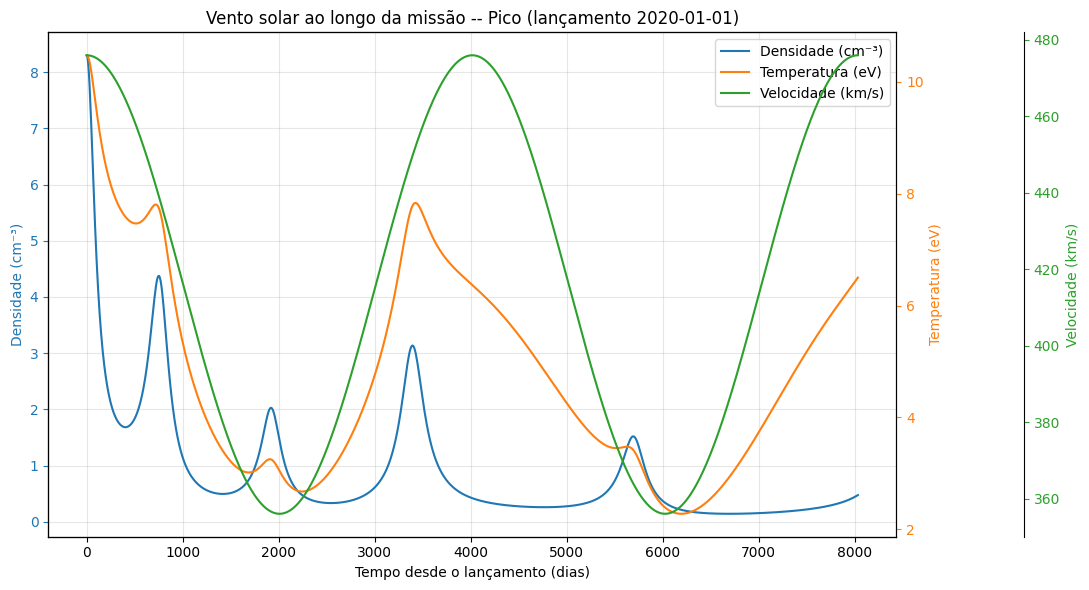

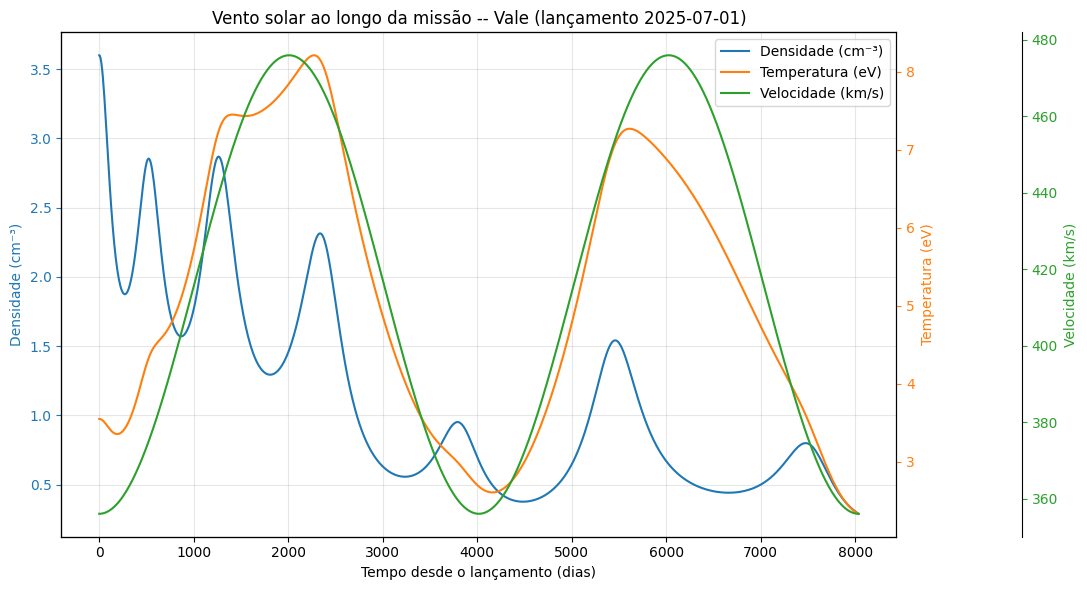

In [4]:
# VENTO SOLAR AO LONGO DE CADA MISSÃO: densidade, temperatura e velocidade
# -- um único gráfico por missão (pico e vale), com as 3 curvas juntas
# (eixos Y triplos, já que as escalas/unidades são bem diferentes).

import numpy as np
import matplotlib.pyplot as plt
from datetime import timedelta

required_wind_plots = ['peak_run', 'trough_run', 'wind_corr']
missing_wind_plots = [name for name in required_wind_plots if name not in globals()]
if missing_wind_plots:
    raise RuntimeError(
        'Execute primeiro as células anteriores. Variáveis ausentes: {}'.format(
            ', '.join(missing_wind_plots)
        )
    )

# Amostragem: uma missão de 22 anos pode ter dezenas de milhares de pontos
# de integração -- reduzimos para no máximo MAX_POINTS igualmente espaçados,
# suficiente para ver a senoide sem pesar o gráfico.
MAX_POINTS = 3000


def wind_profile(run, max_points=MAX_POINTS):
    df_run = run['df']
    launch_date = run['launch_date']

    n_rows = len(df_run)
    step = max(1, n_rows // max_points)
    sample_idx = np.arange(0, n_rows, step)

    elapsed_days, dens_vals, temp_vals, vel_vals = [], [], [], []
    for idx in sample_idx:
        row = df_run.iloc[idx]
        date = launch_date + timedelta(seconds=float(row['T']))
        relative = np.array([
            row['X1'] - row['X0'], row['Y1'] - row['Y0'], row['Z1'] - row['Z0'],
        ])
        radius_m = float(np.linalg.norm(relative)) * 1000.0
        n, te, v, _ = wind_corr.at_distance(date, radius_m)

        elapsed_days.append(row['T'] / 86400.0)
        dens_vals.append(n / 1e6)   # m^-3 -> cm^-3 (mesma unidade do CSV)
        temp_vals.append(te)        # eV
        vel_vals.append(v)          # km/s

    return {
        'elapsed_days': np.array(elapsed_days),
        'density_cm3': np.array(dens_vals),
        'temperature_eV': np.array(temp_vals),
        'speed_km_s': np.array(vel_vals),
    }


def plot_wind_triple(run, profile):
    color_dens, color_temp, color_vel = 'tab:blue', 'tab:orange', 'tab:green'

    fig, ax1 = plt.subplots(figsize=(11, 6))
    ax2 = ax1.twinx()
    ax3 = ax1.twinx()
    ax3.spines['right'].set_position(('axes', 1.15))

    l1, = ax1.plot(
        profile['elapsed_days'], profile['density_cm3'],
        color=color_dens, label='Densidade (cm⁻³)',
    )
    l2, = ax2.plot(
        profile['elapsed_days'], profile['temperature_eV'],
        color=color_temp, label='Temperatura (eV)',
    )
    l3, = ax3.plot(
        profile['elapsed_days'], profile['speed_km_s'],
        color=color_vel, label='Velocidade (km/s)',
    )

    ax1.set_xlabel('Tempo desde o lançamento (dias)')
    ax1.set_ylabel('Densidade (cm⁻³)', color=color_dens)
    ax2.set_ylabel('Temperatura (eV)', color=color_temp)
    ax3.set_ylabel('Velocidade (km/s)', color=color_vel)

    ax1.tick_params(axis='y', colors=color_dens)
    ax2.tick_params(axis='y', colors=color_temp)
    ax3.tick_params(axis='y', colors=color_vel)

    ax1.set_title(
        'Vento solar ao longo da missão -- {} (lançamento {})'.format(
            run['label'], run['launch_date'].strftime('%Y-%m-%d')
        )
    )
    lines = [l1, l2, l3]
    ax1.legend(lines, [line.get_label() for line in lines], loc='upper right')
    ax1.grid(True, alpha=0.3)
    fig.tight_layout()
    plt.show()


peak_wind_profile = wind_profile(peak_run)
trough_wind_profile = wind_profile(trough_run)

plot_wind_triple(peak_run, peak_wind_profile)
plot_wind_triple(trough_run, trough_wind_profile)
